### Preparação de variáveis para cálculo do LRI

**Variáveis:**

- Elevation
- Slope
- Aspect

In [3]:
dem = '/code/data/dem_centro/dem_pnse.tif' #caminho alterado
slope = None
aspect = None


out_slope = '/code/data/slope/slope_ctr.tif'
out_aspect = '/code/data/aspect/aspect_ctr.tif'


rcls_dem = '/code/data/dem/ctr_rcls_dem.tif'
rcls_slope = '/code/data/slope/ctr_rcls_slope.tif'
rcls_aspect = '/code/data/aspect/ctr_rcls_aspect.tif'

In [7]:
import os
from glass.ete.lri import HeuristicLri

In [8]:
# Start Class
lri = HeuristicLri(os.path.dirname(dem), dem, loc=None)

# Import topographic variables

lri.import_topo_vars(dem=dem, slope=slope, aspect=aspect)

In [9]:
# Generate Slope and Aspect if necessary
if not slope or not aspect:
    lri.gen_slope_aspect(
        rst_slope=out_slope,
        rst_aspect=out_aspect
    )

In [10]:
# Reclassify Topographic Variables

lri.recls_topo(
    rcls_dem=rcls_dem,
    rcls_slope=rcls_slope,
    rcls_aspect=rcls_aspect
)

('/code/data/dem/ctr_rcls_dem.tif',
 '/code/data/slope/ctr_rcls_slope.tif',
 '/code/data/aspect/ctr_rcls_aspect.tif')

In [6]:
##verificação - limpar depois


import numpy as np
import rasterio
import os

def raster_summary(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype(float)
        nodata = src.nodata

    if nodata is not None:
        arr[arr == nodata] = np.nan

    vals = arr[~np.isnan(arr)]

    print(os.path.basename(path))
    print("  mínimo:", np.min(vals))
    print("  máximo:", np.max(vals))
    print("  média:", np.mean(vals))
    print("  desvio padrão:", np.std(vals))
    print("  percentis:", np.percentile(vals, [1, 5, 25, 50, 75, 95, 99]))
    print()

raster_summary(dem)
raster_summary(out_slope)
raster_summary(out_aspect)

dem_pnse.tif
  mínimo: 270.0
  máximo: 1990.0
  média: 985.606129234635
  desvio padrão: 341.00398198586294
  percentis: [ 397.46457886  499.95712891  717.03973389  957.9263916  1202.01367188
 1616.4026123  1833.2635791 ]

slope_ctr.tif
  mínimo: 0.0
  máximo: 74.49044799804688
  média: 16.824923928168005
  desvio padrão: 9.623116416009157
  percentis: [ 0.          0.83828264  9.46785665 16.30611038 23.67101383 33.12505131
 39.58920666]

aspect_ctr.tif
  mínimo: -1.0
  máximo: 360.0
  média: 186.99211337020373
  desvio padrão: 110.24659398626271
  percentis: [ -1.           3.47852097  94.85741425 187.42576599 291.44702148
 342.85699158 356.46924988]



In [12]:
# veficr reclassificcados

def raster_unique(path, max_show=20):
    with rasterio.open(path) as src:
        arr = src.read(1)
        nodata = src.nodata

    if nodata is not None:
        arr = arr[arr != nodata]
    else:
        arr = arr.flatten()

    vals, counts = np.unique(arr, return_counts=True)

    print(os.path.basename(path))
    print("  nº de valores únicos:", len(vals))
    print("  valores:", vals[:max_show])
    print("  contagens:", counts[:max_show])
    print()

raster_unique(rcls_dem)
raster_unique(rcls_slope)
raster_unique(rcls_aspect)

ctr_rcls_dem.tif
  nº de valores únicos: 10
  valores: [ 3  4  5  6  7  8  9 10 11 12]
  contagens: [   7769   83884  354189  786408  847420  862802  924939 1030303 3219712
  795763]

ctr_rcls_slope.tif
  nº de valores únicos: 5
  valores: [1 2 3 4 5]
  contagens: [ 975469 1411995 1629014 1588094 3281460]

ctr_rcls_aspect.tif
  nº de valores únicos: 9
  valores: [1 2 3 4 5 6 7 8 9]
  contagens: [ 385318 1027258  811678 1020487 1133381  946838  839652 1136045 1585375]



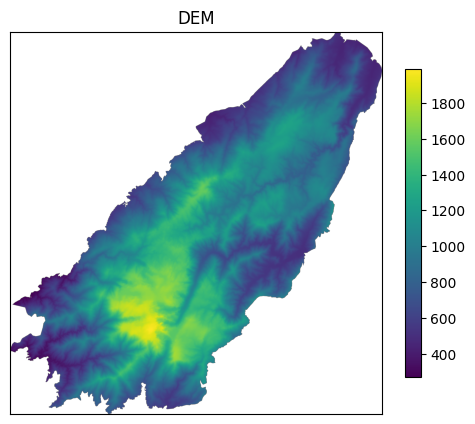

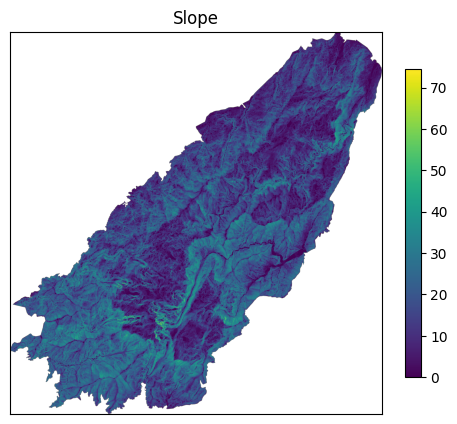

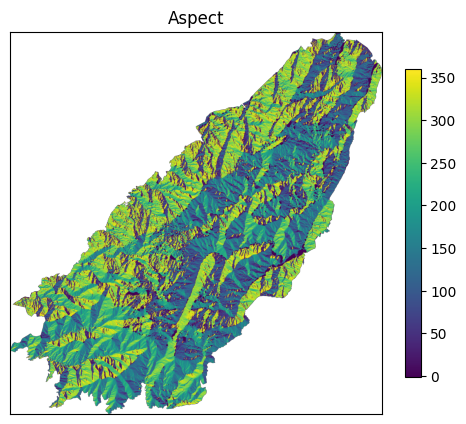

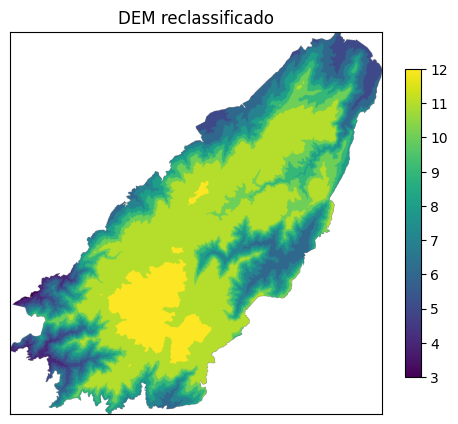

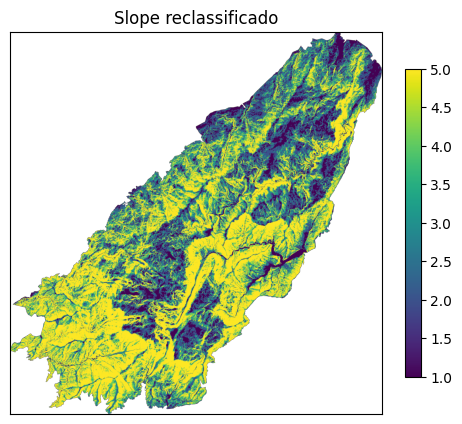

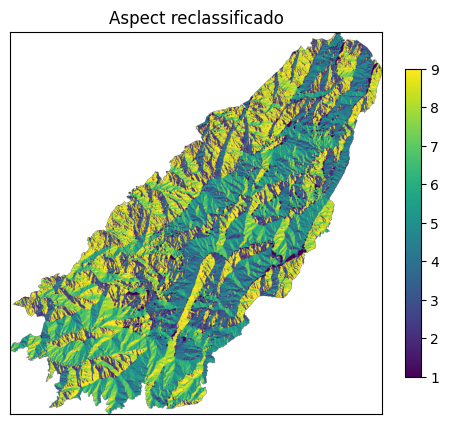

In [14]:
import matplotlib.pyplot as plt

def quick_plot(path, title):
    with rasterio.open(path) as src:
        arr = src.read(1).astype(float)
        nodata = src.nodata

    if nodata is not None:
        arr[arr == nodata] = np.nan

    plt.figure(figsize=(6, 5))
    plt.imshow(arr)
    plt.title(title)
    plt.xticks([])
    plt.yticks([])
    plt.colorbar(shrink=0.8)
    plt.show()

quick_plot(dem, "DEM")
quick_plot(out_slope, "Slope")
quick_plot(out_aspect, "Aspect")

quick_plot(rcls_dem, "DEM reclassificado")
quick_plot(rcls_slope, "Slope reclassificado")
quick_plot(rcls_aspect, "Aspect reclassificado")